# Atelier : Audit d'équité et gestion du risque de modèle en Actuariat

**Public cible :** Élèves-actuaires et étudiants en data science actuarielle.

Bienvenue dans cet atelier complet. Durant cette journée, nous allons simuler un projet de validation de modèle de A à Z, en mettant un accent particulier sur les aspects d'équité et de conformité, qui sont devenus des compétences fondamentales pour l'actuaire moderne.

### Le Scénario

Vous êtes un actuaire-data scientist dans une compagnie d'assurance. On vous confie la mission d'évaluer trois modèles prédictifs du risque de mortalité hospitalière avant une éventuelle utilisation pour la tarification ou la sélection des risques. Votre rôle n'est pas seulement de dire quel modèle est le plus "performant", mais de produire un audit complet qui couvre la performance, l'interprétabilité et, surtout, l'équité.

### Sommaire

- **1. Fondations et Exploration des Données**
  - *Théorie :* D'où viennent les biais ? (Société, Données, Modèle)
  - *Pratique :* Analyse exploratoire critique de nos données.

- **2. Construction et Interprétabilité des Modèles**
  - *Pratique :* Entraînement et optimisation rigoureuse des modèles.
  - *Théorie & Pratique :* Ouvrir la boîte noire avec SHAP pour comprendre ce que les modèles apprennent.

- **3. L'Audit d'Équité Détaillé**
  - *Théorie & Pratique :* Définition, calcul et interprétation actuarielle de 4 métriques d'équité clés.

- **4. Analyse Intersectionnelle et Limites de l'Audit**
  - *Théorie :* Introduction à l'intersectionnalité.
  - *Pratique :* Aller plus loin en analysant les biais sur des sous-groupes croisés (ex: genre et ethnicité).

- **5. Synthèse et Recommandation Professionnelle**
  - *Pratique :* Rédiger une note de synthèse à destination d'un comité de validation de modèle.

--- 
## 1. Fondations et exploration des données (EDA)
---

### 1.1. Théorie : La chaîne de transmission des biais

Un biais algorithmique n'apparaît pas par magie. Il est souvent le produit d'une chaîne de transmission :

1.  **Biais Sociétal :** Des inégalités historiques ou structurelles existent dans le monde réel (ex: accès inégal aux soins, disparités de revenus).
2.  **Biais dans les Données :** Ces biais sociétaux sont capturés et souvent amplifiés dans les données que nous collectons. Les données ne sont pas neutres ; elles sont le reflet d'un monde biaisé. Par exemple, si un groupe a moins accès aux soins, il sera sous-représenté ou présentera des caractéristiques différentes dans les données hospitalières.
3.  **Biais dans le Modèle :** Un algorithme de machine learning est conçu pour trouver et exploiter les motifs présents dans les données. S'il est entraîné sur des données biaisées, il va non seulement apprendre ces biais, mais potentiellement les systématiser et les renforcer dans ses prédictions.

Notre rôle en tant qu'actuaire est de **détecter** ce biais final dans le modèle, et de comprendre qu'il est souvent le symptôme de problèmes en amont.

### 1.2. Mise en place de l'environnement et chargement des données

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, zipfile, io
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score
from sklearn.calibration import calibration_curve

def load_and_prepare_data(url):
    response = requests.get(url)
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_filename = z.namelist()[0]
        with z.open(csv_filename) as f: df = pd.read_csv(f)
    id_cols = {col for col in df.columns if "id" in col}
    df = df.drop(columns=id_cols)
    nan_threshold = len(df) / 10
    features_to_keep = df.columns[df.isna().sum() < nan_threshold].tolist()
    df_cleaned = df[features_to_keep].dropna().reset_index(drop=True)
    df_cleaned['ethnicity'] = np.where(df_cleaned['ethnicity'] == 'African American', 1, -1)
    return df_cleaned

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)

data_url = "https://github.com/curiousML/curiousml.github.io/raw/master/teaching/DSA/labeled.zip"
df = load_and_prepare_data(data_url)

### 1.3. Analyse Exploratoire Guidée

Regardons la composition de notre jeu de données, en gardant en tête la chaîne de transmission des biais.

In [2]:
print("--- Analyse de la variable cible et des attributs sensibles ---")
print("\nTaux de mortalité global:")
print(df['hospital_death'].value_counts(normalize=True))

print("\nDistribution de l'ethnicité:")
print(df['ethnicity'].replace({1: 'Afro-Américain', -1: 'Autre'}).value_counts(normalize=True))

print("\nTaux de mortalité par groupe ethnique:")
print(df.groupby('ethnicity')['hospital_death'].mean().rename(index={1: 'Afro-Américain', -1: 'Autre'}))


--- Analyse de la variable cible et des attributs sensibles ---

Taux de mortalité global:
hospital_death
0    0.914521
1    0.085479
Name: proportion, dtype: float64

Distribution de l'ethnicité:
ethnicity
Autre             0.891222
Afro-Américain    0.108778
Name: proportion, dtype: float64

Taux de mortalité par groupe ethnique:
ethnicity
Autre             0.086953
Afro-Américain    0.073400
Name: hospital_death, dtype: float64


#### **Exercice guidé 1 : Réflexion sur les biais potentiels dans les données**

1.  Le groupe 'Afro-Américain' est minoritaire dans nos données (environ 10%). Comment la sous-représentation d'un groupe peut-elle influencer la performance d'un modèle pour ce même groupe ?
2.  Nous observons que le **taux de mortalité réel** est différent entre les deux groupes. Est-ce que cela justifie qu'un modèle ait un comportement différent pour ces groupes ? Pourquoi est-ce une question complexe et délicate pour un actuaire ?

--- 
## 2. Construction et interprétabilité des modèles
---

### 2.1. Préparation des données pour la modélisation

In [3]:
features_cat = ["apache_2_bodysystem", "icu_admit_source"]
features_ord = ["gender"]
features_num = ["age", "bmi", "immunosuppression", "d1_sysbp_min", "d1_spo2_min", "d1_glucose_max"]
feature_sens = "ethnicity"
feature_target = "hospital_death"
feature_blackbox = "apache_4a_hospital_death_prob"

df_model = df[features_cat + features_ord + features_num + [feature_sens, feature_target, feature_blackbox]].copy()
df_model['gender'] = LabelEncoder().fit_transform(df_model['gender'])
df_model = pd.get_dummies(df_model, columns=features_cat, dummy_na=False)

X = df_model.drop(columns=[feature_target, feature_blackbox])
y = df_model[feature_target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

s_train = X_train[feature_sens].copy()
s_test = X_test[feature_sens].copy()
blackbox_scores = df_model.loc[X_test.index, feature_blackbox]
X_train_final = X_train.drop(columns=feature_sens)
X_test_final = X_test.drop(columns=feature_sens)

### 2.2. Entraînement des modèles
Nous entraînons d'abord une Régression Logistique comme modèle de base, puis nous optimisons un LightGBM pour obtenir la meilleure performance possible.

In [4]:
# Modèle 1 : Régression Logistique
log_reg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_final, y_train)

# Modèle 2 : LightGBM avec optimisation des hyperparamètres
param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'num_leaves': [20, 31, 40]}
lgbm = lgb.LGBMClassifier(random_state=42)
random_search = RandomizedSearchCV(lgbm, param_distributions=param_grid, n_iter=5, cv=3, scoring='roc_auc', random_state=42)
random_search.fit(X_train_final, y_train)
best_lgbm = random_search.best_estimator_

# Génération des prédictions (probabilités)
probas_logreg = log_reg.predict_proba(X_test_final)[:, 1]
probas_lgbm = best_lgbm.predict_proba(X_test_final)[:, 1]
probas_blackbox = blackbox_scores.values

print("--- Performance Globale (AUC) ---")
print(f"Régression Logistique : {roc_auc_score(y_test, probas_logreg):.4f}")
print(f"LightGBM (optimisé)   : {roc_auc_score(y_test, probas_lgbm):.4f}")
print(f"Score Blackbox        : {roc_auc_score(y_test, probas_blackbox):.4f}")

Exception in thread Thread-4:
Traceback (most recent call last):
  File "c:\Users\francois.hu\AppData\Local\miniforge3\envs\fair_loan_project\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "c:\Users\francois.hu\AppData\Local\miniforge3\envs\fair_loan_project\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\francois.hu\AppData\Local\miniforge3\envs\fair_loan_project\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\francois.hu\AppData\Local\miniforge3\envs\fair_loan_project\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\francois.hu\AppData\Local\miniforge3\envs\fair_loan_project\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 133: invalid start byte


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2378, number of negative: 25442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 27820, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085478 -> initscore=-2.370142
[LightGBM] [Info] Start training from score -2.370142
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2378, number of negative: 25443
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

### 2.3. Interprétabilité : Que regardent nos modèles ?
Un actuaire doit pouvoir justifier les décisions de son modèle. Pour un modèle complexe comme le LightGBM, nous pouvons utiliser des outils comme **SHAP** (*SHapley Additive exPlanations*) pour comprendre quelles variables ont le plus d'impact sur les prédictions.

Calcul des valeurs SHAP pour le modèle LightGBM...


c:\Users\francois.hu\AppData\Local\miniforge3\envs\fair_loan_project\lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


Affichage de l'importance globale des variables (SHAP Summary Plot):


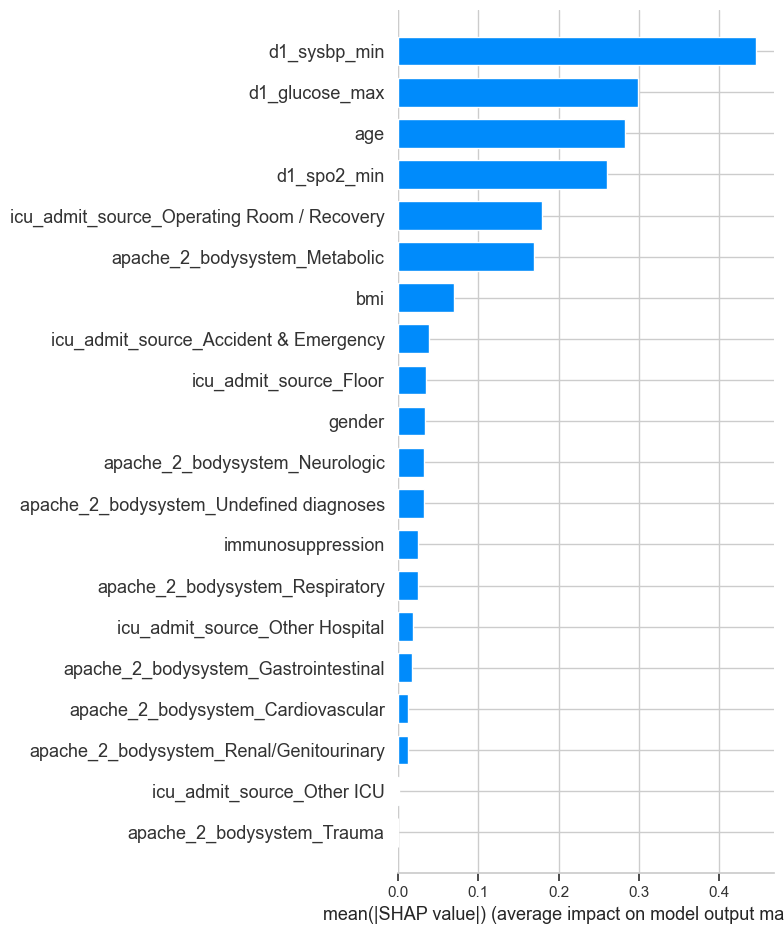

In [6]:
print("Calcul des valeurs SHAP pour le modèle LightGBM...")
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test_final)

# Note: SHAP pour les modèles de classification binaire retourne une liste de deux arrays (un pour chaque classe).
# Nous nous intéressons à l'impact sur la classe positive (Décès = 1).
shap_values_class1 = shap_values

print("Affichage de l'importance globale des variables (SHAP Summary Plot):")
shap.summary_plot(shap_values_class1, X_test_final, plot_type="bar")

#### **Exercice guidé 2 : Interprétation des facteurs de risque**

Le graphique ci-dessus montre les variables qui ont, en moyenne, le plus grand impact sur les prédictions du modèle LightGBM.
1.  Quelles sont les 3 variables les plus importantes selon le modèle ?
2.  Ces facteurs de risque vous semblent-ils logiques d'un point de vue médical ou actuariel ? Pourquoi est-ce une étape de validation importante ?
3.  La variable `gender` (genre) a un certain impact. Si le genre était un critère de segmentation interdit par la réglementation pour ce produit d'assurance, que signifierait cette observation pour le déploiement du modèle ?

--- 
## 3. L'Audit d'équité algorithmique
---

Maintenant que nous avons nos meilleurs modèles, nous allons les auditer en détail. Nous commençons par trouver les seuils de décision optimaux pour chaque modèle afin de les comparer sur une base équitable.

In [9]:
def find_optimal_threshold_youden(y_true, y_probas):
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_probas)
    return thresholds[np.argmax(tpr - fpr)]

thresh_logreg = find_optimal_threshold_youden(y_test, probas_logreg)
thresh_lgbm = find_optimal_threshold_youden(y_test, probas_lgbm)
thresh_blackbox = find_optimal_threshold_youden(y_test, probas_blackbox)

preds_logreg = (probas_logreg >= thresh_logreg).astype(int)
preds_lgbm = (probas_lgbm >= thresh_lgbm).astype(int)
preds_blackbox = (probas_blackbox >= thresh_blackbox).astype(int)

### 3.1. Test 1 : Parité Démographique
**Rappel :** Mesure si le modèle classe le même pourcentage d'individus comme "à risque" dans chaque groupe.

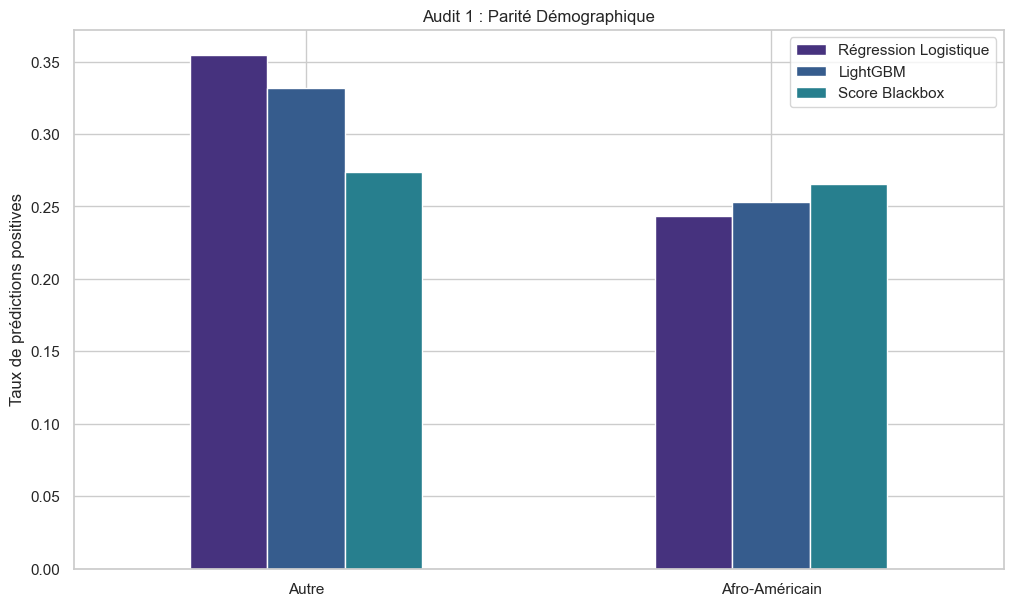

In [11]:
# Le code corrigé, plus lisible et plus efficace
group_labels = {-1: "Autre", 1: "Afro-Américain"}
demographic_parity_logreg = pd.Series(preds_logreg, index=s_test.index).groupby(s_test).mean().to_dict()
demographic_parity_lgbm = pd.Series(preds_lgbm, index=s_test.index).groupby(s_test).mean().to_dict()
demographic_parity_blackbox = pd.Series(preds_blackbox, index=s_test.index).groupby(s_test).mean().to_dict()

# Le reste du code reste identique
df_dp = pd.DataFrame({
    'Régression Logistique': demographic_parity_logreg,
    'LightGBM': demographic_parity_lgbm,
    'Score Blackbox': demographic_parity_blackbox
}).rename(index=group_labels)

df_dp.plot(kind='bar', rot=0).set(title='Audit 1 : Parité Démographique', ylabel='Taux de prédictions positives')
plt.show()

### 3.2. Test 2 : Parité Prédictive
**Rappel :** Mesure si la **précision** du modèle est la même pour chaque groupe (qualité des "alertes").

[Text(0.5, 1.0, 'Audit 2 : Parité Prédictive (Précision)'),
 Text(0, 0.5, 'Précision des prédictions positives')]

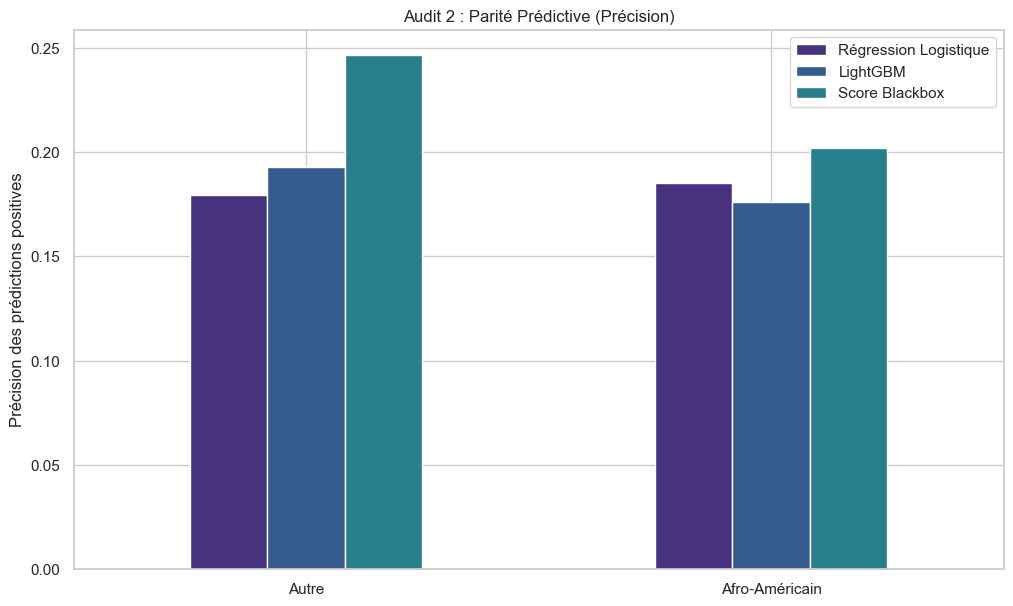

In [12]:
def calculate_metric_by_group(y_true, y_pred, s_test, metric_func):
    scores = {}
    for group_id in np.unique(s_test):
        mask = (s_test == group_id)
        scores[group_id] = metric_func(y_true[mask], y_pred[mask])
    return scores

predictive_parity_logreg = calculate_metric_by_group(y_test, preds_logreg, s_test, lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0))
predictive_parity_lgbm = calculate_metric_by_group(y_test, preds_lgbm, s_test, lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0))
predictive_parity_blackbox = calculate_metric_by_group(y_test, preds_blackbox, s_test, lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0))
df_pp = pd.DataFrame({'Régression Logistique': predictive_parity_logreg, 'LightGBM': predictive_parity_lgbm, 'Score Blackbox': predictive_parity_blackbox}).rename(index=group_labels)
df_pp.plot(kind='bar', rot=0).set(title='Audit 2 : Parité Prédictive (Précision)', ylabel='Précision des prédictions positives')

### 3.3. Test 3 : Égalité des Chances
**Rappel :** Mesure si le **rappel** du modèle est le même pour chaque groupe (capacité à détecter les vrais risques).

[Text(0.5, 1.0, 'Audit 3 : Égalité des Chances (Rappel)'),
 Text(0, 0.5, 'Taux de vrais risques détectés')]

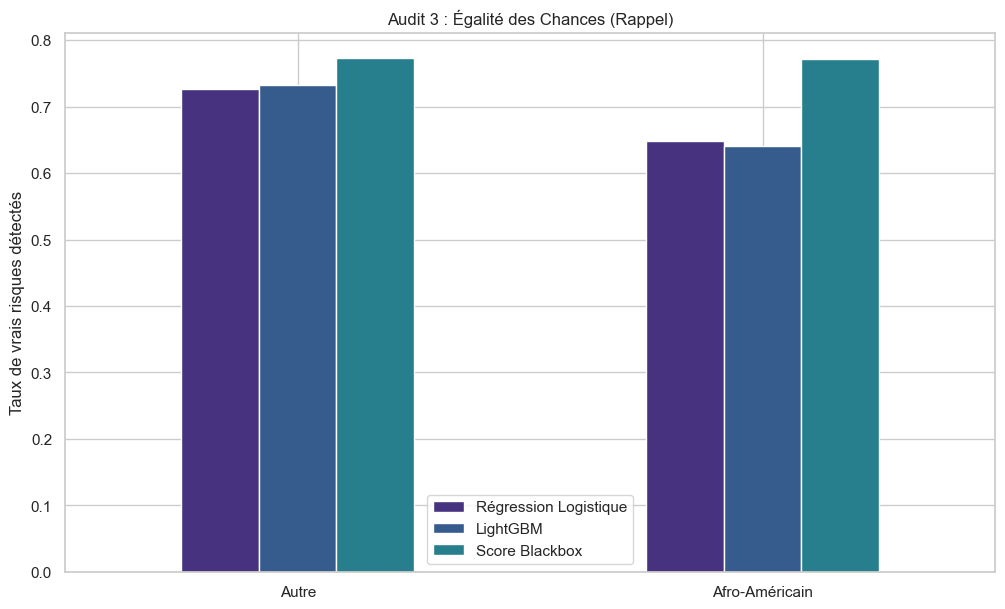

In [13]:
equal_opportunity_logreg = calculate_metric_by_group(y_test, preds_logreg, s_test, lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0))
equal_opportunity_lgbm = calculate_metric_by_group(y_test, preds_lgbm, s_test, lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0))
equal_opportunity_blackbox = calculate_metric_by_group(y_test, preds_blackbox, s_test, lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0))
df_eo = pd.DataFrame({'Régression Logistique': equal_opportunity_logreg, 'LightGBM': equal_opportunity_lgbm, 'Score Blackbox': equal_opportunity_blackbox}).rename(index=group_labels)
df_eo.plot(kind='bar', rot=0).set(title='Audit 3 : Égalité des Chances (Rappel)', ylabel='Taux de vrais risques détectés')

### 3.4. Test 4 : Calibration par Groupe
**Rappel :** Vérifie si les scores de probabilité sont fiables pour chaque groupe.

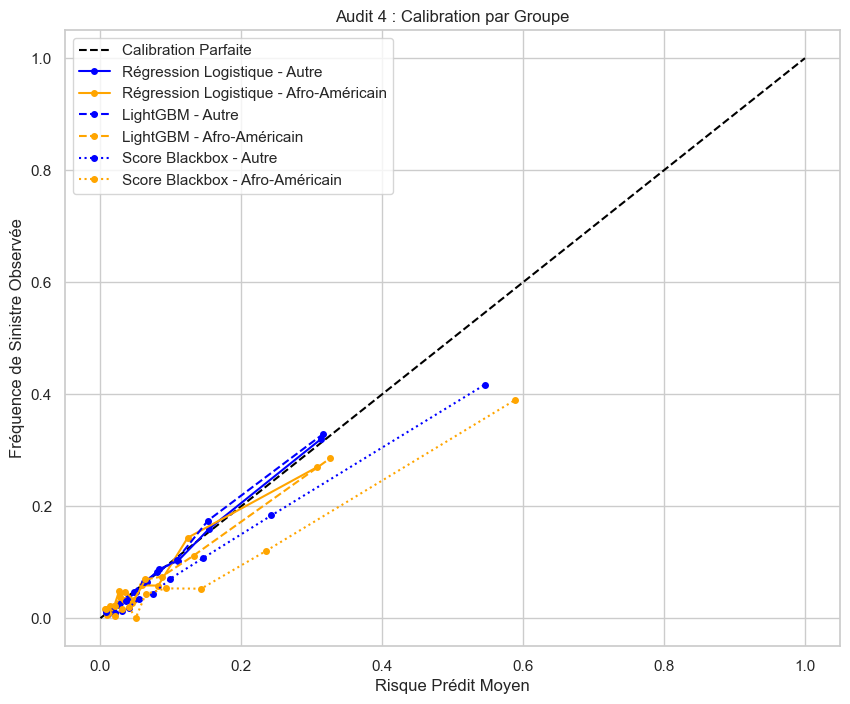

In [17]:
def plot_calibration_curves(probas_dict, y_test, s_test, group_labels):
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', label='Calibration Parfaite')
    
    colors = {'Autre': 'blue', 'Afro-Américain': 'orange'}
    linestyles = {'Régression Logistique': '-', 'LightGBM': '--', 'Score Blackbox': ':'}
    
    for model_name, probas in probas_dict.items():
        # **CORRECTIF DÉFINITIF APPLIQUÉ ICI**
        # Nous nous assurons que les probabilités sont bien dans l'intervalle [0, 1]
        # à l'intérieur de la fonction, la rendant robuste.
        probas_cleaned = np.clip(probas, 0, 1)
        
        for group_id, group_name in group_labels.items():
            mask = (s_test == group_id)
            
            # On vérifie qu'il y a des données et au moins deux classes (positifs et négatifs) dans le sous-groupe
            if mask.sum() > 0 and len(np.unique(y_test[mask])) > 1:
                # Nous utilisons maintenant les probabilités nettoyées
                prob_true, prob_pred = calibration_curve(y_test[mask], probas_cleaned[mask], n_bins=10, strategy='quantile')
                plt.plot(prob_pred, prob_true, marker='o', markersize=4, linestyle=linestyles[model_name], 
                         color=colors[group_name], label=f'{model_name} - {group_name}')

    plt.xlabel('Risque Prédit Moyen')
    plt.ylabel('Fréquence de Sinistre Observée')
    plt.title('Audit 4 : Calibration par Groupe')
    plt.legend()
    plt.grid(True)
    plt.show()

# La ligne d'appel reste la même et fonctionnera maintenant
probas_dict = {'Régression Logistique': probas_logreg, 'LightGBM': probas_lgbm, 'Score Blackbox': probas_blackbox}
plot_calibration_curves(probas_dict, y_test.values, s_test.values, group_labels)

#### **Exercice guidé 3 : Synthèse de l'audit**

1.  **Le biais le plus critique :** Sur la base des quatre graphiques, quel est, selon vous, le biais le plus flagrant et le plus dangereux d'un point de vue actuariel, commun aux trois modèles ? Justifiez.
2.  **Le meilleur compromis (si vous deviez choisir) :** Si vous étiez forcé de choisir l'un des trois modèles sur la base de cet audit, lequel choisiriez-vous ? Argumentez en pesant la performance (AUC), l'interprétabilité et les différents types de biais.
3.  **L'énigme du Blackbox :** Le score Blackbox, bien que très performant, présente un fort biais sur l'Égalité des Chances mais une excellente calibration. Comment expliquez-vous cette apparente contradiction ?

--- 
## 4. Analyse Intersectionnelle et limites de l'audit
---

### 4.1. Théorie : Au-delà d'un seul attribut
Jusqu'à présent, nous avons analysé le biais selon un seul axe : l'ethnicité. Mais les biais peuvent être plus complexes. L'**intersectionnalité** est un concept qui nous rappelle que les discriminations peuvent se cumuler et se produire aux **intersections** de plusieurs identités.

Un modèle peut sembler équitable pour les 'femmes' en général et pour les 'Afro-Américains' en général, mais être très biaisé contre le groupe des **'femmes Afro-Américaines'**.

Nous allons mener une analyse rapide pour voir si de tels biais existent dans notre modèle le plus performant, le LightGBM.

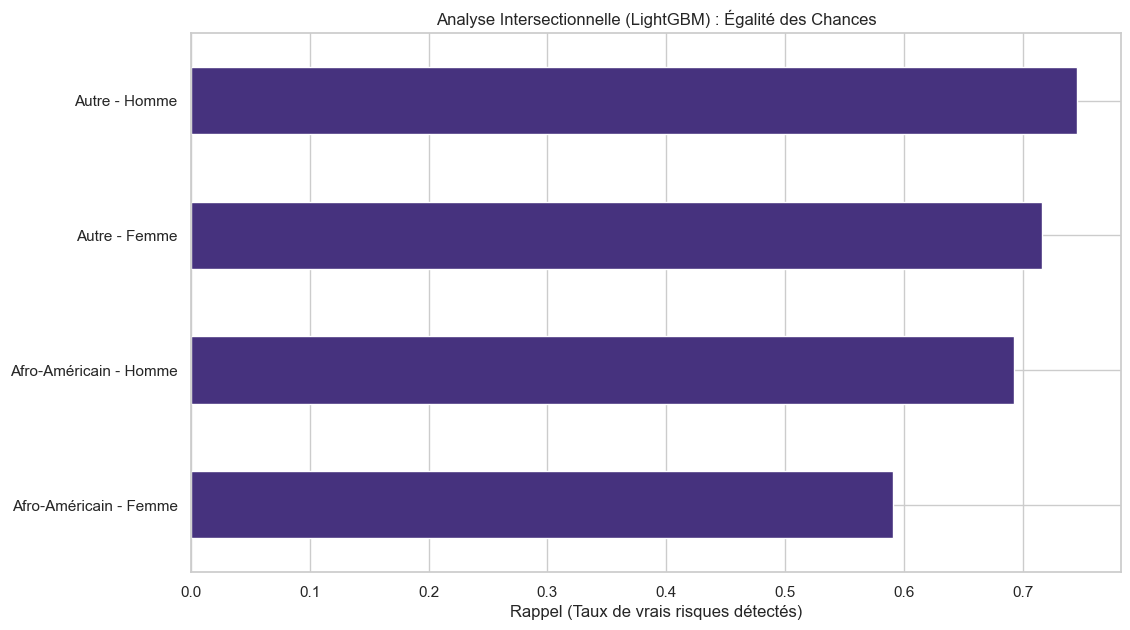

In [16]:
# Création des groupes intersectionnels
s_test_gender = X_test['gender'].map({0: 'Femme', 1: 'Homme'})
s_test_ethnicity = s_test.map({-1: 'Autre', 1: 'Afro-Américain'})
intersectional_group = s_test_ethnicity + ' - ' + s_test_gender

# Audit de l'Égalité des Chances (Rappel) sur les groupes intersectionnels pour le LightGBM
recall_intersectional_lgbm = {}
df_inter = pd.DataFrame({'y_true': y_test, 'y_pred': preds_lgbm, 'group': intersectional_group})
for group_name, group_df in df_inter.groupby('group'):
    recall_intersectional_lgbm[group_name] = recall_score(group_df['y_true'], group_df['y_pred'], zero_division=0)

pd.Series(recall_intersectional_lgbm).sort_values().plot(kind='barh')
plt.title('Analyse Intersectionnelle (LightGBM) : Égalité des Chances')
plt.xlabel('Rappel (Taux de vrais risques détectés)')
plt.show()

#### **Exercice guidé 4 : Interprétation de l'analyse intersectionnelle**

1.  Le graphique ci-dessus montre le rappel du modèle LightGBM pour quatre groupes croisés. Observe-t-on des disparités importantes ?
2.  Quel est le groupe pour lequel le modèle est le **moins performant** (rappel le plus bas) ?
3.  En quoi cette analyse affine-t-elle notre diagnostic initial ? Quel risque aurions-nous pris en nous arrêtant à l'analyse sur le seul axe de l'ethnicité ?

--- 
## 5. Synthèse et recommandation professionnelle
---

Nous sommes au terme de notre journée d'audit. La dernière étape, et la plus importante, est de traduire cette analyse technique complexe en une recommandation claire et actionnable.

#### **Exercice final : Rédaction de la note de synthèse**

Vous devez rédiger un court e-mail ou une note de synthèse (3-4 paragraphes) à destination du **Comité de Validation des Modèles**. Cette note doit être professionnelle, concise et basée sur les preuves que vous avez collectées tout au long de la journée.

Votre note doit inclure :

1.  **Objet :** Audit d'Équité des Modèles de Risque de Mortalité.

2.  **Synthèse des Performances :** Rappelez brièvement la performance globale des trois modèles (RegLog, LGBM, Blackbox) en termes d'AUC.

3.  **Diagnostic des Biais :** Présentez les conclusions principales de l'audit d'équité. Mettez en évidence le ou les biais les plus critiques que vous avez identifiés (par exemple, le manque d'Égalité des Chances et la mauvaise calibration) et le risque actuariel associé (financier, conformité).

4.  **Analyse Intersectionnelle :** Mentionnez brièvement que des biais encore plus profonds existent lorsque l'on croise les attributs de genre et d'ethnicité, et identifiez le sous-groupe le plus à risque.

5.  **Recommandation Finale :**
    -   Statuez clairement si vous recommandez ou non la mise en production de l'un des modèles en l'état.
    -   Proposez un plan d'action clair avec 2 ou 3 prochaines étapes (ex: "Je recommande de ne pas déployer ces modèles pour le moment. Les prochaines étapes devraient être de 1)... 2)... 3)...").

Cet exercice final est le plus important car il simule la manière dont vous communiquerez votre expertise technique pour influencer une décision stratégique.